# CELS / M-CELS Implementation Comparison — FordA

This notebook compares three CELS-family implementations on the **FordA** dataset (univariate, binary classification) using the pretrained SimpleCNN model.

| Variant | Source | Key differences |
|---------|--------|------------------|
| `cels` | `cels.py :: cels_generate` | sklearn NN (flattened), mask `(1,L)`, sigmoid threshold, early-stop=30, user-set target |
| `mcels_reimp` | `mcels_reimp.py :: mcels_generate` | Paper-faithful: tslearn/sklearn NUN on `(C,L)`, flattened TV norm, early-stop=100, auto-target (2nd-probable), threshold=0.5 |
| `mcels_reimp_nobudget` | `mcels_reimp.py :: mcels_generate` | Same reimp but budget (L1) term disabled — isolates the TV-norm contribution |

**References**
- CELS: Li et al., *IEEE BigData 2023*
- M-CELS: Li et al., *arXiv:2411.02649, 2024*

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_cels.cels import cels_generate
from cfts.cf_cels.mcels_reimp import mcels_generate
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


# --- Prediction utilities ---
def predict_scores(model, sample, device):
    """Return softmax scores as (n_classes,) numpy array."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        ts = ts.reshape(1, ts.shape[0], ts.shape[1]) if ts.shape[0] <= ts.shape[1] else ts.T.unsqueeze(0)
    elif ts.ndim == 3:
        if ts.shape[0] != 1:
            ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]  # strip batch dim
    raise ValueError(f"Unsupported shape: {arr.shape}")


# Evaluate model on test set
y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth
Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


In [3]:
# Build background arrays for both API styles
# cels_generate expects (X_train, y_train) as numpy arrays
# mcels_generate expects (background_data, background_labels) as (N, C, L) and int labels

BG_SIZE = min(300, len(dataset_train))

X_bg_raw = np.stack(
    [np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(BG_SIZE)], axis=0
)  # (N, 1, L) for FordA
y_bg_onehot = np.stack(
    [np.asarray(dataset_train[i][1], dtype=np.float32) for i in range(BG_SIZE)], axis=0
)  # (N, n_classes)
y_bg_int = np.argmax(y_bg_onehot, axis=1)  # (N,)

# cels_generate wants X_train shape (N, 1, L) and y_train one-hot
X_train_cels = X_bg_raw
y_train_cels = y_bg_onehot

# mcels_generate wants background_data (N, C, L)
background_data = X_bg_raw  # already (N, 1, L) = (N, C, L) with C=1
background_labels = y_bg_int

# Reference data for feature_range_validity metric
reference_data = X_bg_raw

print(f"Background data: {background_data.shape}, labels: {background_labels.shape}")
print(f"Label distribution: {np.unique(background_labels, return_counts=True)}")

Background data: (300, 1, 500), labels: (300,)
Label distribution: (array([0, 1]), array([157, 143]))


In [4]:
def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """Model callable (N, L) or (C, L) -> scores array for metrics."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def infer_target_class(scores: np.ndarray) -> int:
    return int(np.argsort(scores)[::-1][1])


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def compute_metrics(sample_cf, cf_cf, target_class):
    """Compute quality metrics for (sample, counterfactual) both in (C, L) form."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_wrapper,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, reference_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_wrapper, target_class=target_class)),
    }

In [5]:
N_SAMPLES = 30

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 30 correctly classified test samples.


In [6]:
# Method runners
# Note: mcels_generate auto-selects target (2nd most probable) — we record
# the actual cf_label it used, which may differ from the CELS target.

def run_cels(sample_raw, target_class):
    """CELS from cels.py — univariate, user-specified target."""
    cf, pred_scores = cels_generate(
        sample=sample_raw,
        model=model,
        X_train=X_train_cels,
        y_train=y_train_cels,
        target=target_class,
        learning_rate=0.01,
        max_iter=200,
        lambda_valid=1.0,
        lambda_budget=0.1,
        lambda_tv=0.1,
        verbose=False,
    )
    return cf, pred_scores, target_class


def run_mcels_reimp(sample_raw, target_class, enable_budget=True):
    """M-CELS faithful reimplementation — auto target (2nd most probable)."""
    sample_cl = to_channel_first(sample_raw)  # (1, L)
    mask, cf, target_prob, cf_label = mcels_generate(
        sample=sample_cl,
        model=model,
        background_data=background_data,
        background_labels=background_labels,
        lr=1e-3,
        max_itr=300,
        enable_budget=enable_budget,
        l_budget_coeff=1.0,
        enable_tvnorm=True,
        l_tv_norm_coeff=1.0,
        l_max_coeff=1.0,
        random_state=42,
        verbose=False,
    )
    pred_scores = predict_scores(model, cf, device)
    return cf, pred_scores, cf_label, mask


METHODS = ["cels", "mcels_reimp", "mcels_reimp_nobudget"]
METHOD_COLORS = ["#2a9d8f", "#e76f51", "#264653"]

In [7]:
records = []
all_cfs = {}   # {sample_idx: {method: cf_array}}
all_masks = {} # {sample_idx: {method: mask_array}} — only for reimp methods

for idx in selected_indices:
    sample_raw, label = dataset_test[idx]
    sample_raw = np.asarray(sample_raw, dtype=np.float32)
    scores_orig = predict_scores(model, sample_raw, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    all_cfs[idx] = {"sample": sample_raw, "true_label": true_label, "target_class": target_class}
    all_masks[idx] = {}

    base = {
        "sample_idx": idx,
        "true_label": true_label,
        "pred_orig": pred_orig,
        "target_class": target_class,
    }

    # --- CELS ---
    try:
        cf, pred_scores, used_target = run_cels(sample_raw, target_class)
        if cf is not None and pred_scores is not None:
            cf_cf = to_channel_first(cf)
            sample_cf = to_channel_first(sample_raw)
            pred_cf = int(np.argmax(np.asarray(pred_scores).reshape(-1)))
            success = (pred_cf == used_target)
            metrics = compute_metrics(sample_cf, cf_cf, used_target)
            records.append({**base, "method": "cels", "used_target": used_target,
                            "pred_cf": pred_cf, "success": bool(success), **metrics, "error": None})
            all_cfs[idx]["cels"] = cf
        else:
            records.append({**base, "method": "cels", "used_target": target_class,
                            "pred_cf": None, "success": False, "error": "Returned None"})
    except Exception as exc:
        records.append({**base, "method": "cels", "used_target": target_class,
                        "pred_cf": None, "success": False, "error": f"{type(exc).__name__}: {exc}"})

    # --- M-CELS reimp (with budget) ---
    try:
        cf, pred_scores, cf_label, mask = run_mcels_reimp(sample_raw, target_class, enable_budget=True)
        cf_cf = to_channel_first(cf)
        sample_cf = to_channel_first(sample_raw)
        pred_cf = int(np.argmax(np.asarray(pred_scores).reshape(-1)))
        success = (pred_cf == cf_label)
        metrics = compute_metrics(sample_cf, cf_cf, cf_label)
        records.append({**base, "method": "mcels_reimp", "used_target": cf_label,
                        "pred_cf": pred_cf, "success": bool(success), **metrics, "error": None})
        all_cfs[idx]["mcels_reimp"] = cf
        all_masks[idx]["mcels_reimp"] = mask
    except Exception as exc:
        records.append({**base, "method": "mcels_reimp", "used_target": target_class,
                        "pred_cf": None, "success": False, "error": f"{type(exc).__name__}: {exc}"})

    # --- M-CELS reimp (no budget) ---
    try:
        cf, pred_scores, cf_label, mask = run_mcels_reimp(sample_raw, target_class, enable_budget=False)
        cf_cf = to_channel_first(cf)
        sample_cf = to_channel_first(sample_raw)
        pred_cf = int(np.argmax(np.asarray(pred_scores).reshape(-1)))
        success = (pred_cf == cf_label)
        metrics = compute_metrics(sample_cf, cf_cf, cf_label)
        records.append({**base, "method": "mcels_reimp_nobudget", "used_target": cf_label,
                        "pred_cf": pred_cf, "success": bool(success), **metrics, "error": None})
        all_cfs[idx]["mcels_reimp_nobudget"] = cf
        all_masks[idx]["mcels_reimp_nobudget"] = mask
    except Exception as exc:
        records.append({**base, "method": "mcels_reimp_nobudget", "used_target": target_class,
                        "pred_cf": None, "success": False, "error": f"{type(exc).__name__}: {exc}"})

results_df = pd.DataFrame(records)
print(f"Evaluation complete. Total records: {len(results_df)}")
results_df.head(9)

Evaluation complete. Total records: 90


,sample_idx,true_label,pred_orig,target_class,method,used_target,pred_cf,success,l2_norm,dtw_proximity,normalized_distance,sparsity,range_validity,autocorr,keane_validity,keane_proximity,keane_compactness,validity,error
0,0,0,0,1,cels,1,1,True,26.218973,11.432794,0.194649,0.064,0.950,0.826165,1.0,26.218973,0.068,1.0,None
1,0,0,0,1,mcels_reimp,1,0,False,9.172605,6.333560,0.068097,0.744,0.952,0.986533,0.0,9.172605,0.746,0.0,None
2,0,0,0,1,mcels_reimp_nobudget,1,0,False,13.873897,8.306771,0.102999,0.490,0.962,0.940858,0.0,13.873897,0.494,0.0,None
3,1,0,0,1,cels,1,0,False,0.000000,0.000000,0.000000,1.000,0.962,1.000000,0.0,0.000000,1.000,0.0,None
4,1,0,0,1,mcels_reimp,1,0,False,9.285460,5.595527,0.074056,0.742,0.970,0.991215,0.0,9.285460,0.750,0.0,None
5,1,0,0,1,mcels_reimp_nobudget,1,0,False,12.961610,6.976939,0.103375,0.510,0.984,0.975644,0.0,12.961610,0.518,0.0,None
6,2,0,0,1,cels,1,1,True,22.054836,10.619904,0.113963,0.058,0.944,0.998223,1.0,22.054836,0.060,1.0,None
7,2,0,0,1,mcels_reimp,1,0,False,10.954265,7.653977,0.056604,0.602,0.944,0.999718,0.0,10.954265,0.604,0.0,None
8,2,0,0,1,mcels_reimp_nobudget,1,0,False,11.775152,8.079255,0.060845,0.514,0.948,0.999588,0.0,11.775152,0.518,0.0,None


In [8]:
# Aggregate summary
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)

display_cols = [
    "method", "n_successful", "success_rate", "validity_mean",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "range_validity_mean", "autocorr_mean",
    "keane_proximity_mean", "keane_compactness_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,validity_mean,l2_norm_mean,dtw_proximity_mean,sparsity_mean,range_validity_mean,autocorr_mean,keane_proximity_mean,keane_compactness_mean
0,cels,27,90.0,0.9000,21.1750,9.5980,0.2332,0.9496,0.9711,21.1750,0.2370
1,mcels_reimp,8,26.7,0.2667,9.4878,5.8824,0.6585,0.9642,0.9996,9.4878,0.6615
2,mcels_reimp_nobudget,13,43.3,0.4333,10.7097,5.9589,0.5051,0.9682,0.9977,10.7097,0.5109


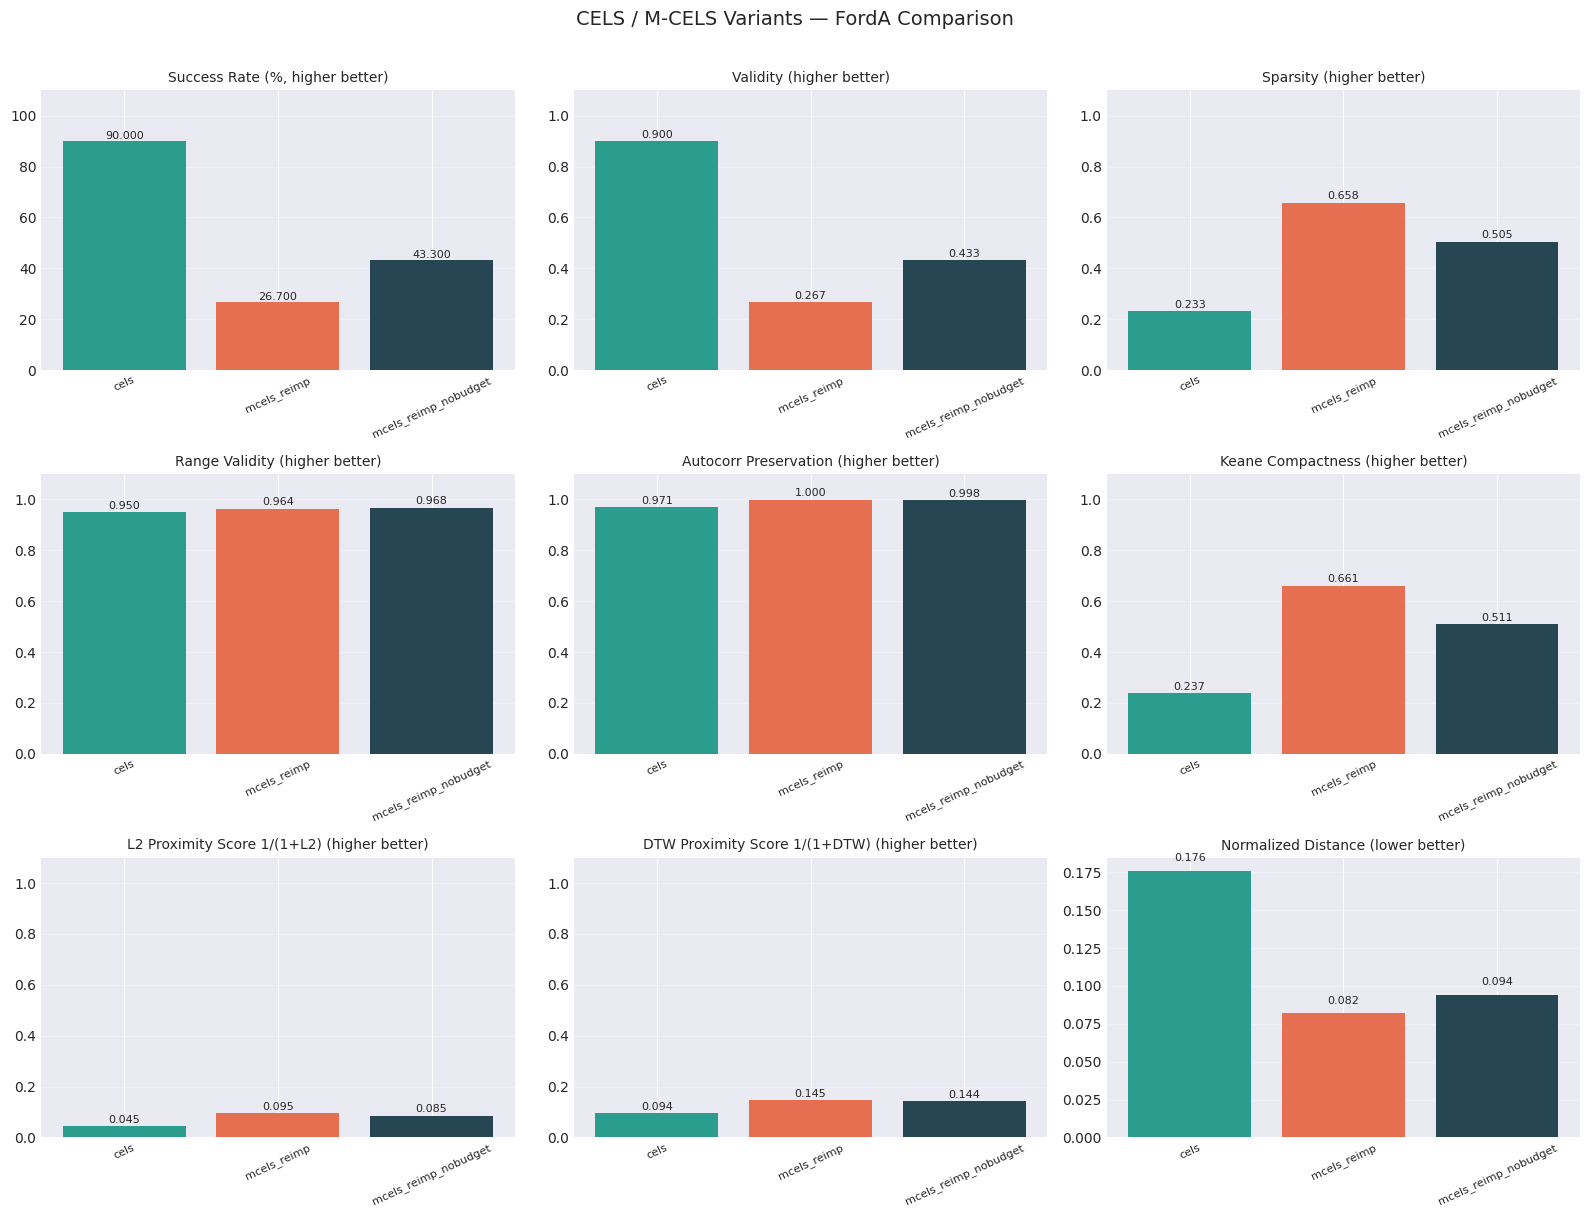

In [9]:
plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = METHOD_COLORS[: len(methods)]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"].fillna(np.inf))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("CELS / M-CELS Variants — FordA Comparison", fontsize=14, y=1.01)

bar(axes[0, 0], plot_df["success_rate"], "Success Rate (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["validity_mean"].fillna(0), "Validity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[1, 0], plot_df["range_validity_mean"].fillna(0), "Range Validity (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], plot_df["autocorr_mean"].fillna(0), "Autocorr Preservation (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["keane_compactness_mean"].fillna(0), "Keane Compactness (higher better)", ylim=(0, 1.1))
bar(axes[2, 0], l2_score, "L2 Proximity Score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[2, 1], dtw_score, "DTW Proximity Score 1/(1+DTW) (higher better)", ylim=(0, 1.1))
bar(axes[2, 2], plot_df["normalized_distance_mean"].fillna(np.nan), "Normalized Distance (lower better)")

plt.tight_layout()
plt.show()

In [10]:
# Pick a representative sample where all (or as many as possible) methods succeeded
success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)

full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(METHODS)]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])

print(f"Representative sample index: {rep_idx}")
print(f"Methods succeeded: {int(success_counts[rep_idx])} / {len(METHODS)}")

Representative sample index: 26
Methods succeeded: 3 / 3


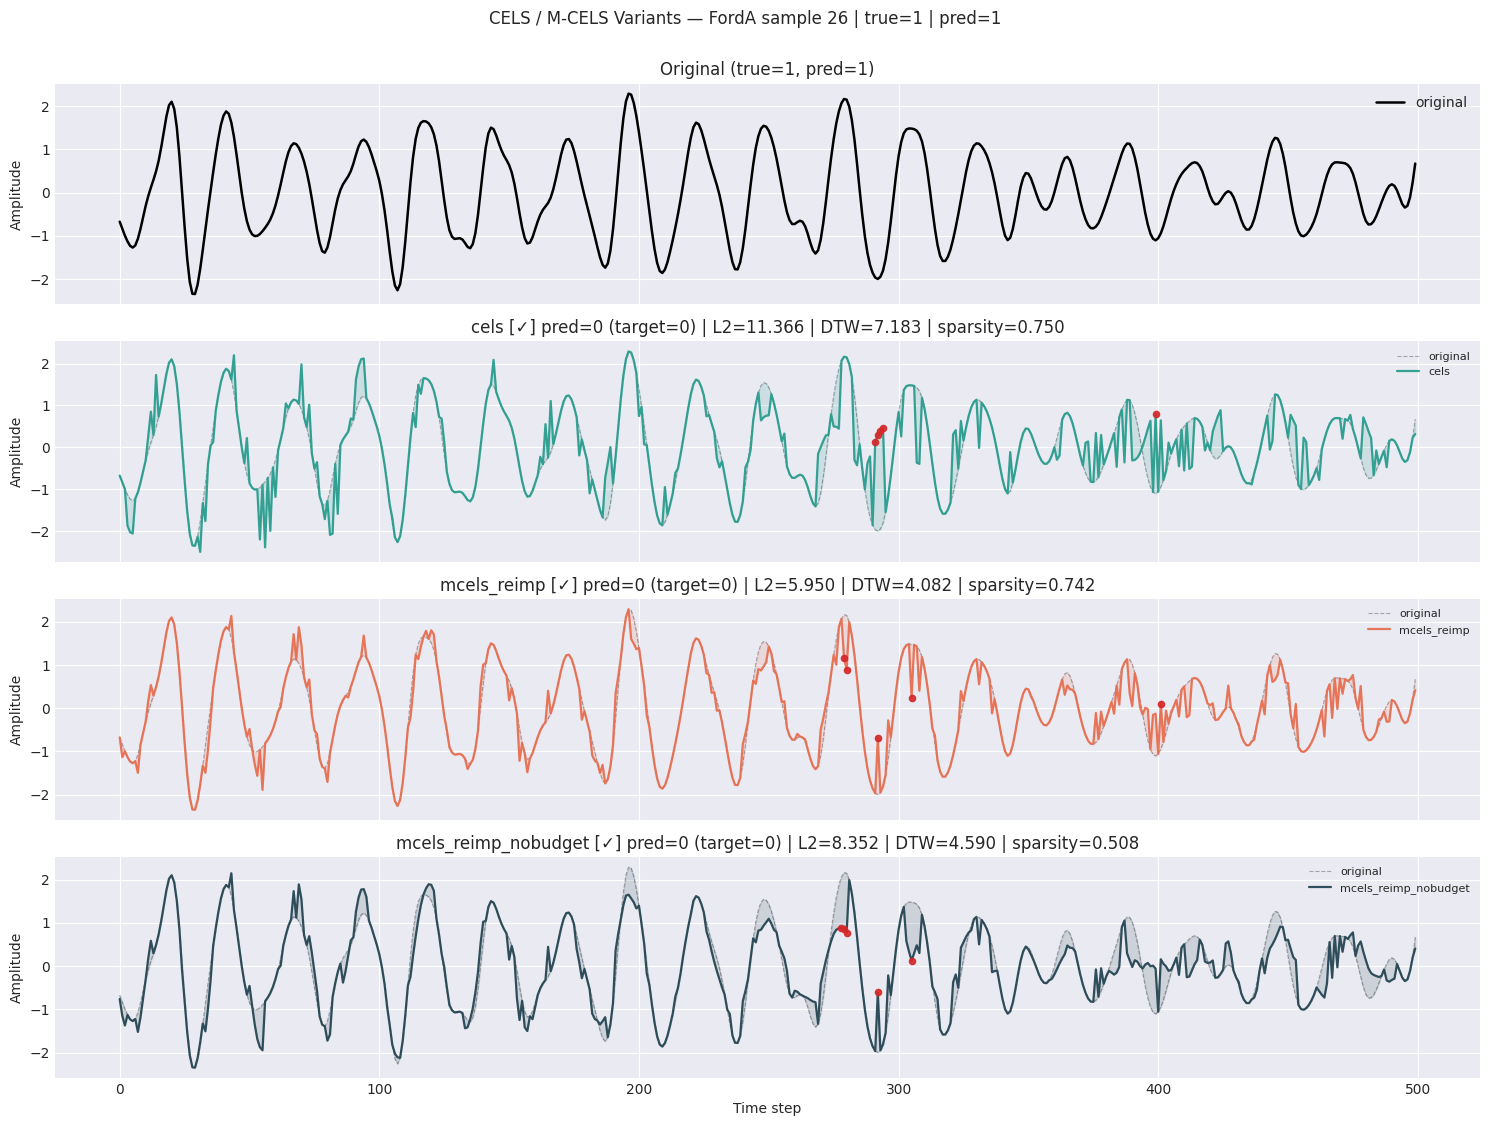

In [11]:
# Waveform comparison: original vs each variant
rep = all_cfs[rep_idx]
x = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x))

sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if not pd.isna(row.get("pred_cf", np.nan)) else None,
        "used_target": int(row["used_target"]) if not pd.isna(row.get("used_target", np.nan)) else None,
        "l2": float(row["l2_norm"]) if not pd.isna(row.get("l2_norm", np.nan)) else np.nan,
        "dtw": float(row["dtw_proximity"]) if not pd.isna(row.get("dtw_proximity", np.nan)) else np.nan,
        "sparsity": float(row["sparsity"]) if not pd.isna(row.get("sparsity", np.nan)) else np.nan,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])

n_rows = 1 + len(METHODS)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(
    f"CELS / M-CELS Variants — FordA sample {rep_idx} | true={true_label} | pred={pred_orig}",
    fontsize=12, y=1.001,
)

axes[0].plot(x, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig})")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

for i, method_name in enumerate(METHODS, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    used_target = info.get("used_target")
    l2_val = info.get("l2", np.nan)
    dtw_val = info.get("dtw", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_line = to_channel_first(cf)[0]
        ax.plot(cf_line, linewidth=1.6, alpha=0.95, color=METHOD_COLORS[i - 1], label=method_name)
        ax.fill_between(x_axis, x, cf_line, color=METHOD_COLORS[i - 1], alpha=0.15)
        diff_abs = np.abs(cf_line - x)
        top_idx = np.argsort(diff_abs)[-5:] if diff_abs.size >= 5 else np.arange(diff_abs.size)
        ax.scatter(x_axis[top_idx], cf_line[top_idx], s=20, color="#d62728", alpha=0.9, zorder=4)

    status = "✓" if worked else "✗"
    ax.set_title(
        f"{method_name} [{status}] pred={pred_cf} (target={used_target}) "
        f"| L2={l2_val:.3f} | DTW={dtw_val:.3f} | sparsity={sp_val:.3f}"
    )
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

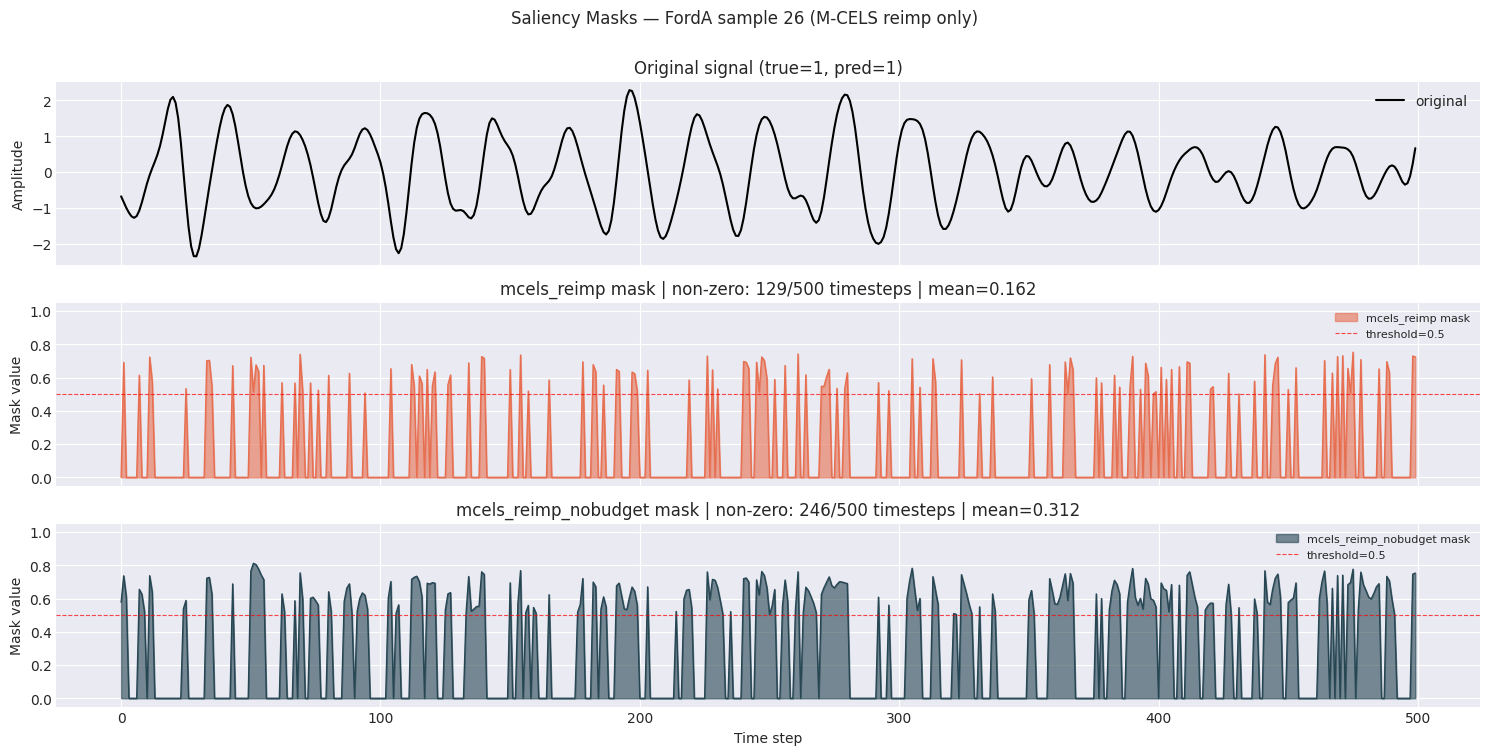

In [12]:
# Saliency mask comparison for the reimp methods
# (CELS from cels.py doesn't expose the mask directly in its return value)
reimp_methods = [m for m in METHODS if m.startswith("mcels_reimp")]
reimp_colors = METHOD_COLORS[1:]

masks_available = [m for m in reimp_methods if all_masks[rep_idx].get(m) is not None]

if masks_available:
    fig, axes = plt.subplots(len(masks_available) + 1, 1,
                             figsize=(15, 2.5 * (len(masks_available) + 1)), sharex=True)
    fig.suptitle(
        f"Saliency Masks — FordA sample {rep_idx} (M-CELS reimp only)",
        fontsize=12, y=1.001,
    )

    # Top: original waveform for reference
    axes[0].plot(x, color="black", linewidth=1.5, label="original")
    axes[0].set_title(f"Original signal (true={true_label}, pred={pred_orig})")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend()

    for i, method_name in enumerate(masks_available, start=1):
        ax = axes[i]
        mask_arr = all_masks[rep_idx][method_name]
        mask_1d = np.asarray(mask_arr, dtype=np.float32).reshape(-1)
        color = reimp_colors[reimp_methods.index(method_name)]
        ax.fill_between(x_axis, 0, mask_1d, color=color, alpha=0.6, label=f"{method_name} mask")
        ax.plot(mask_1d, color=color, linewidth=1.0)
        ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="threshold=0.5")
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("Mask value")
        ax.set_title(
            f"{method_name} mask | non-zero: {np.sum(mask_1d > 0.5)}/{len(mask_1d)} timesteps "
            f"| mean={mask_1d.mean():.3f}"
        )
        ax.legend(fontsize=8)

    axes[-1].set_xlabel("Time step")
    plt.tight_layout(rect=[0, 0, 1, 0.998])
    plt.show()
else:
    print("No masks available for this sample.")

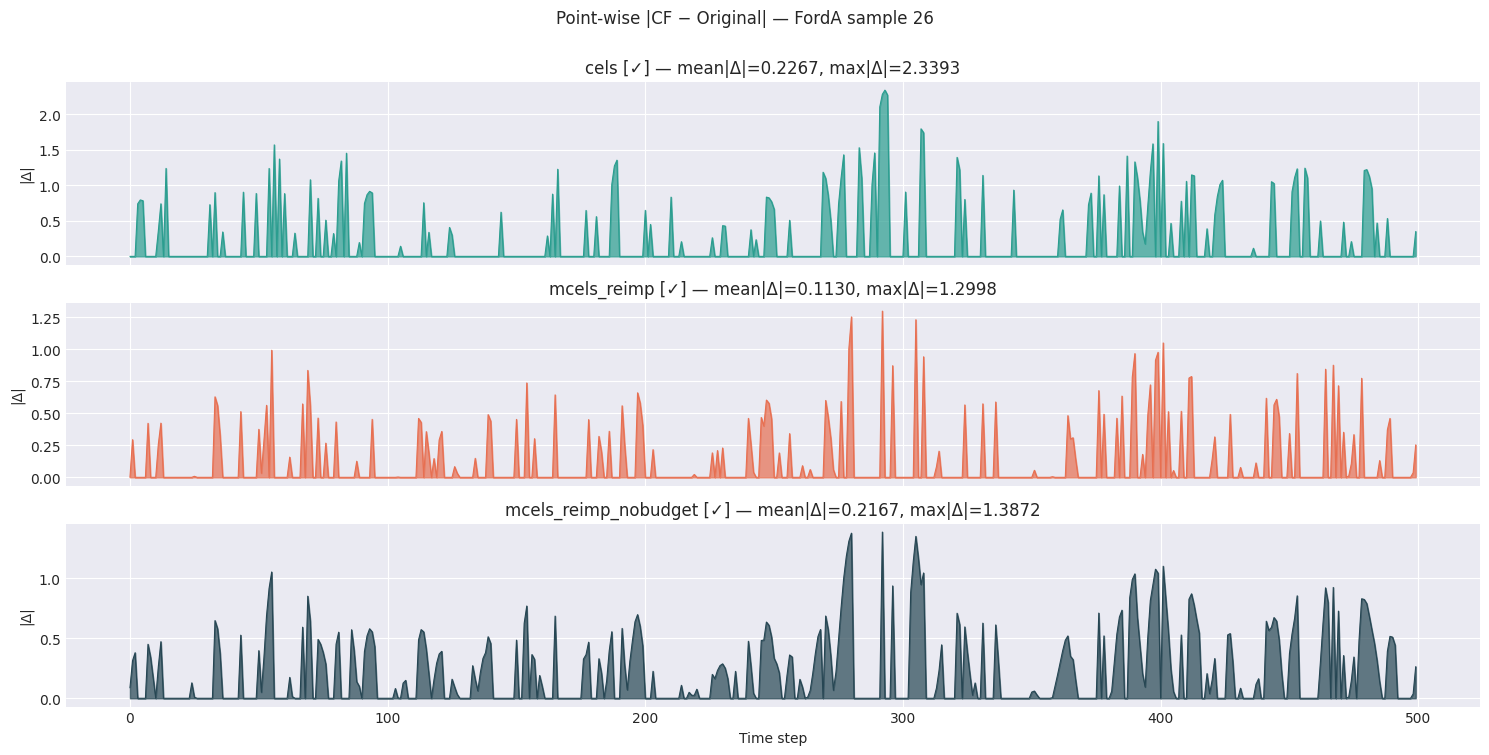

In [13]:
# Point-wise |CF − original| for each method
fig, axes = plt.subplots(len(METHODS), 1, figsize=(15, 2.5 * len(METHODS)), sharex=True)
fig.suptitle(f"Point-wise |CF − Original| — FordA sample {rep_idx}", fontsize=12, y=1.001)

for i, method_name in enumerate(METHODS):
    ax = axes[i]
    cf = rep.get(method_name)
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method_name)
        continue
    diff = np.abs(to_channel_first(cf)[0] - x)
    info = info_lookup.get(method_name, {})
    status = "✓" if info.get("success", False) else "✗"
    ax.fill_between(x_axis, 0, diff, color=METHOD_COLORS[i], alpha=0.7)
    ax.plot(diff, color=METHOD_COLORS[i], linewidth=0.8)
    ax.set_title(f"{method_name} [{status}] — mean|Δ|={diff.mean():.4f}, max|Δ|={diff.max():.4f}")
    ax.set_ylabel("|Δ|")

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

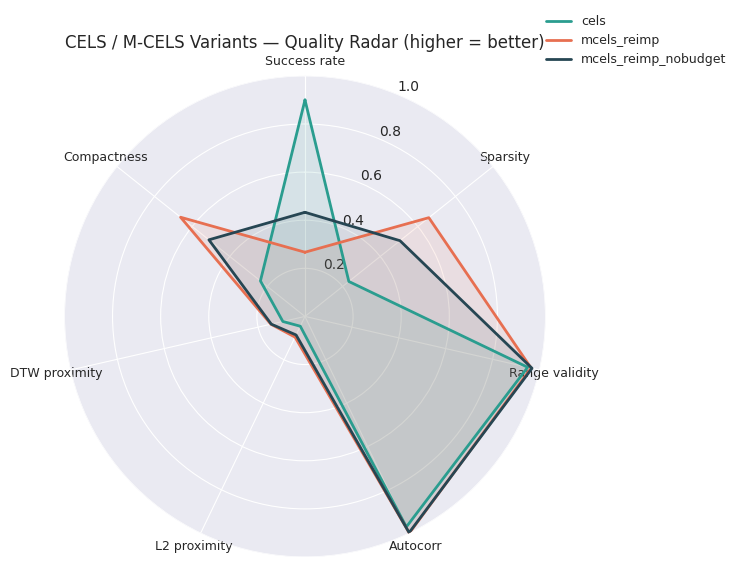

In [14]:
# Radar chart summarising key metrics
radar_metrics = [
    "success_rate_norm", "sparsity_mean", "range_validity_mean",
    "autocorr_mean", "l2_score", "dtw_score", "keane_compactness_mean",
]
radar_labels = [
    "Success rate", "Sparsity", "Range validity",
    "Autocorr", "L2 proximity", "DTW proximity", "Compactness",
]

plot_df2 = plot_df.copy()
plot_df2["success_rate_norm"] = plot_df2["success_rate"] / 100.0
plot_df2["l2_score"] = 1.0 / (1.0 + plot_df2["l2_norm_mean"].fillna(np.inf))
plot_df2["dtw_score"] = 1.0 / (1.0 + plot_df2["dtw_proximity_mean"].fillna(np.inf))

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_ylim(0, 1)

for row_i, row in plot_df2.iterrows():
    vals = [float(row.get(m, 0) or 0) for m in radar_metrics]
    vals += vals[:1]
    color = METHOD_COLORS[row_i % len(METHOD_COLORS)]
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=row["method"], color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_title("CELS / M-CELS Variants — Quality Radar (higher = better)", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Check alignment between inferred target_class and the auto-selected cf_label in reimp methods
# (CELS uses the user-specified target; reimp always picks 2nd most probable)
target_check = results_df[["sample_idx", "method", "target_class", "used_target", "success"]].copy()
target_check["target_match"] = target_check["target_class"] == target_check["used_target"]

print("Target alignment between inferred target and method's used target:")
print(target_check.groupby("method")[["target_match", "success"]].mean().round(3))

Target alignment between inferred target and method's used target:
                      target_match  success
method                                     
cels                           1.0    0.900
mcels_reimp                    1.0    0.267
mcels_reimp_nobudget           1.0    0.433


In [16]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.
